<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº1: Síntesis y operaciones de señales
#### Ivana Rocio Miranda



## Introducción

El presente trabajo aborda el análisis de **señales en tiempo discreto**, tanto desde su generación como desde el procesamiento mediante sistemas LTI (Lineales e Invariantes en el Tiempo).

### Conceptos fundamentales

**Señal sinusoidal discreta:**  
Una señal sinusoidal discreta se expresa como:

$$x[n] = A \cdot \sin(2\pi f_0 n T_s + \phi) + DC$$

donde $A$ es la amplitud, $f_0$ la frecuencia, $T_s = 1/f_s$ el período de muestreo, y $\phi$ la fase inicial.

**Período y clasificación energía/potencia:**  
- Una señal **periódica** de duración infinita (como una sinusoide) tiene energía infinita pero **potencia finita** → es una **señal de potencia**.  
- Una señal de duración finita (como un pulso rectangular) tiene energía finita → es una **señal de energía**.

**Modulación en amplitud (AM):**  
La modulación AM combina una señal mensaje $m(t)$ con una portadora $\cos(2\pi f_c t)$:

$$y(t) = [1 + m(t)] \cdot \cos(2\pi f_c t)$$

En el dominio frecuencial, la modulación desplaza el espectro de la señal mensaje hacia la frecuencia de la portadora $f_c$, generando bandas laterales simétricas.

**Convolución y sistemas LTI:**  
La salida de un sistema LTI ante una entrada $x[n]$ se calcula como la convolución discreta con su respuesta al impulso $h[n]$:

$$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n-k]$$

El sistema utilizado en este trabajo es:
$$h[n] = \delta[n] - \delta[n-4]$$

Este sistema actúa como un **filtro diferenciador con retardo 4**, resaltando cambios en la señal separados 4 muestras.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

def mi_funcion_cuadrada(vmax, dc, ff, nn, fs):
    ts = 1/fs
    yy = np.arange(nn) * ts
    cc = dc + vmax * np.sign(np.sin(2*np.pi*ff*yy))
    return yy, cc

def mi_funcion_pulso_rect(vmax, dc, ancho, nn, fs):
    tt = np.arange(nn) / fs
    xx = np.full(nn, dc, dtype=float)
    ancho_muestras = int(ancho * fs)
    xx[:ancho_muestras] = vmax + dc
    return tt, xx

---
## Ejercicio 1 – Generación y análisis de señales

En cada caso se indica el **período**, el **número de muestras** y si se trata de una **señal de potencia o de energía**.

### Inciso 1 – Señal sinusoidal de 2 kHz

Se genera una señal sinusoidal pura de frecuencia $f_0 = 2000$ Hz con amplitud unitaria, sin offset de continua y sin desfase inicial. Se usan $N = 100$ muestras tomadas a $f_s = 10000$ Hz.

- **Período:** $T = 1/f_0 = 0.5$ ms → a $f_s = 10\,\text{kHz}$, cada período contiene $f_s/f_0 = 5$ muestras, por lo que las 100 muestras cubren **20 períodos completos**.
- **Número de muestras:** $N = 100$  
- **Clasificación:** Señal de **potencia** (sinusoide periódica → energía infinita, potencia media finita $P = A^2/2 = 0.5$ W).

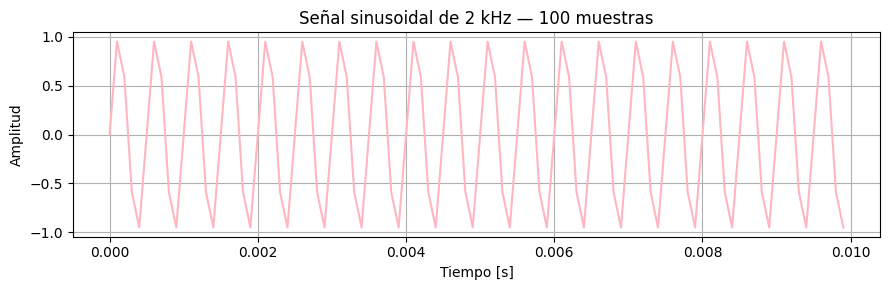

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx
    
N = 100
fs = 10000
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N, fs=fs)

plt.figure(figsize=(9,3))
plt.plot(tt, xx, color='lightpink')
plt.title("Señal sinusoidal de 2 kHz — 100 muestras")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

### Inciso 2 – Señal amplificada 3 dB y desfasada en π/2

Se parte de la misma señal de 2 kHz, pero se la amplifica 3 dB y se le agrega un desfase de $\phi = \pi/2$.

Amplificar 3 dB en términos de tensión equivale a multiplicar la amplitud por $10^{3/20} \approx 1.414$ (factor $\sqrt{2}$). El desfase de $\pi/2$ convierte la sinusoide en una cosinusoide (máximo en $t=0$).

- **Período y muestras:** idénticos al inciso anterior ($T = 0.5$ ms, $N = 100$).
- **Clasificación:** Señal de **potencia** ($P = A^2/2 \approx 1$ W tras la amplificación).

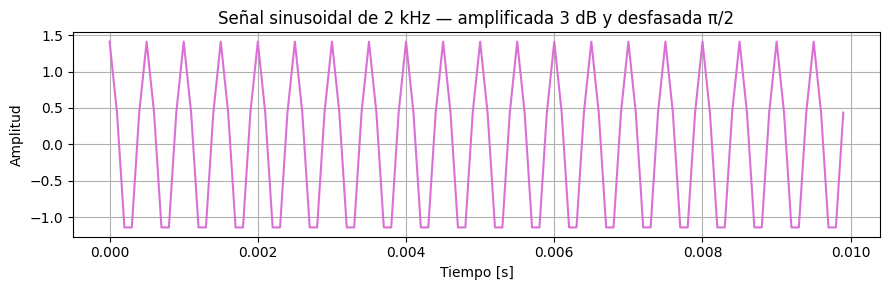

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx
    
dB = 3
A = 10**(dB/20)
_, xx2 = mi_funcion_sen(vmax=A, dc=0, ff=2000, ph=np.pi/2, nn=N, fs=fs)

plt.figure(figsize=(9,3))
plt.plot(tt, xx2, color='orchid')
plt.title("Señal sinusoidal de 2 kHz — amplificada 3 dB y desfasada π/2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

### Inciso 3 – Modulación en amplitud (AM)

La señal de 2 kHz es modulada en amplitud por una portadora de $f_c = 10$ kHz (en el código se usa esa frecuencia, también denominada 10 kHz). La señal modulada es:

$$y(t) = [1 + x(t)] \cdot \cos(2\pi f_c t)$$

Se emplean $N = 100\,000$ muestras a $f_s \approx 2$ MHz para capturar correctamente tanto la señal mensaje como la portadora.

**Fenómeno observable:** En el dominio del tiempo se aprecia cómo la envolvente de la portadora replica la forma de $1 + x(t)$. En la FFT se observan **tres picos**: la componente en DC ($f = 0$ → portadora pura), y las **bandas laterales** en $f_c \pm f_0$ (es decir, a 8 kHz y 12 kHz), características de la AM.

- **Clasificación:** Señal de **potencia** (la modulada es periódica).

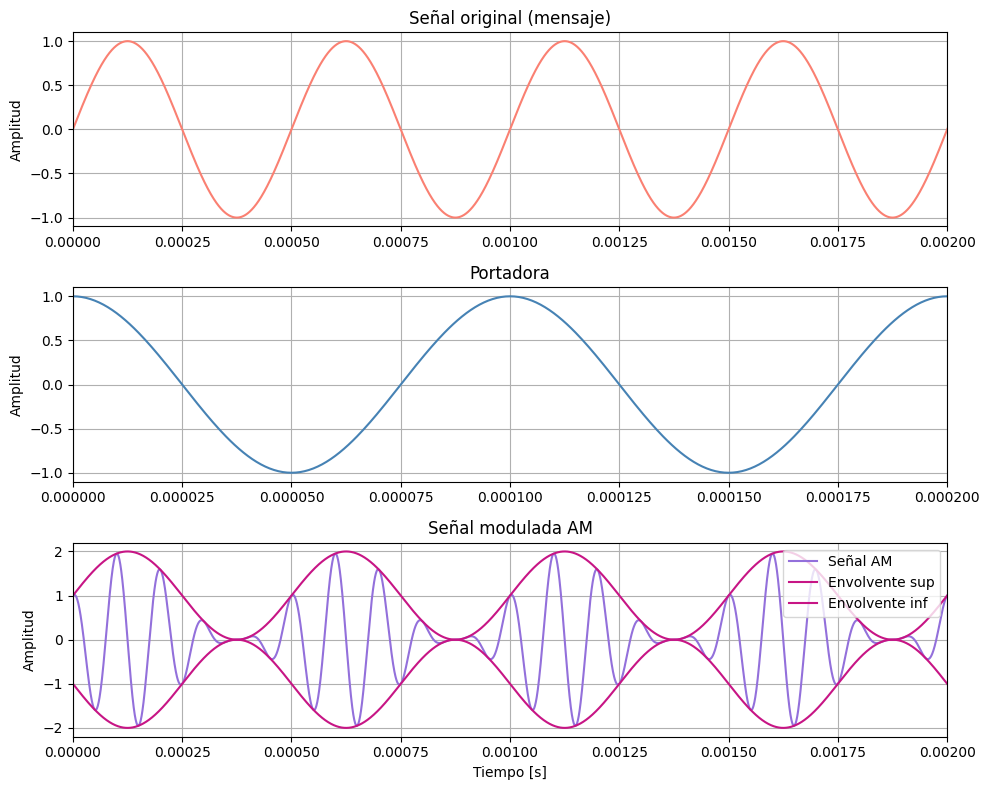

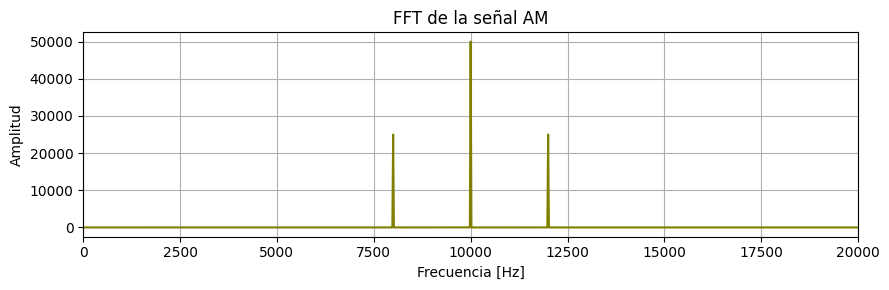

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

N3 = 100000
fs3 = 2000001

tt3, xx3 = mi_funcion_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N3, fs=fs3)
fc = 10000
portadora = np.cos(2*np.pi*fc*tt3)
y = (1 + xx3) * portadora

YY = np.fft.fft(y)
YYmod = np.abs(YY)
df = fs3 / N3
ff_fft = np.arange(N3) * df

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(tt3, xx3, color='salmon')
axes[0].set_xlim(0, 0.002)
axes[0].set_title("Señal original (mensaje)")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

axes[1].plot(tt3, portadora, color='steelblue')
axes[1].set_xlim(0, 0.0002)
axes[1].set_title("Portadora")
axes[1].set_ylabel("Amplitud")
axes[1].grid(True)

axes[2].plot(tt3, y, color='mediumpurple', label="Señal AM")
axes[2].plot(tt3, (1+xx3), 'mediumvioletred', label="Envolvente sup")
axes[2].plot(tt3, -(1+xx3), 'mediumvioletred', label="Envolvente inf")
axes[2].set_xlim(0, 0.002)
axes[2].set_title("Señal modulada AM")
axes[2].set_xlabel("Tiempo [s]")
axes[2].set_ylabel("Amplitud")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

b = ff_fft <= fs3/2
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], YYmod[b], color='olive')
plt.xlim(0, 20000)
plt.title("FFT de la señal AM")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

### Inciso 4 – Señal con saturación al 75% de amplitud

Se aplica un efecto de **saturación** (clipping) a la señal original del inciso 1, limitando su amplitud al 75% del máximo ($A_{sat} = 0.75$ V). Esto simula la distorsión no lineal que ocurre en amplificadores llevados a su límite.

**Fenómeno observable:** La señal recortada presenta **mesetas planas** en los picos, aproximando una forma de onda cuadrada. En el dominio frecuencial, este recorte genera **armónicos impares** (3°, 5°, 7°...) que no estaban presentes en la sinusoide original, evidenciando la distorsión armónica total (THD).

- **Período:** igual a la señal original (0.5 ms); el recorte no modifica la periodicidad.  
- **Clasificación:** Señal de **potencia**.

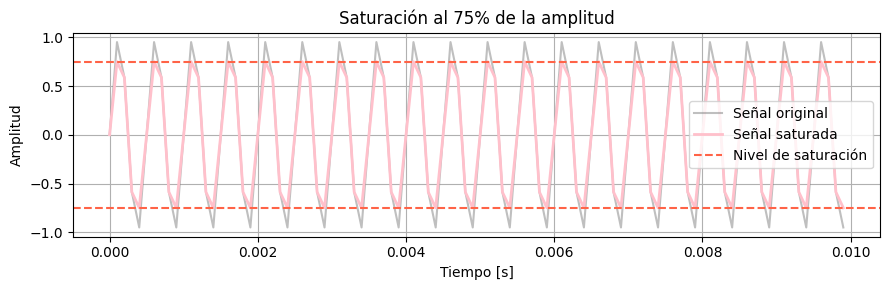

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx
    
sat = 0.75 * 1
xx_sat = np.clip(xx, -sat, sat)

plt.figure(figsize=(9,3))
plt.plot(tt, xx, color='gray', label="Señal original", alpha=0.5)
plt.plot(tt, xx_sat, color='pink', label="Señal saturada", linewidth=2)
plt.axhline(sat, color='tomato', linestyle='--', label='Nivel de saturación')
plt.axhline(-sat, color='tomato', linestyle='--')
plt.title("Saturación al 75% de la amplitud")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Inciso 5 – Señal cuadrada de 4 kHz

Se genera una señal cuadrada de $f_0 = 4000$ Hz usando la función signo aplicada sobre una sinusoide. Se usan $N = 100$ muestras a $f_s = 100\,000$ Hz, lo que da una resolución de $f_s/f_0 = 25$ muestras por período.

**Fenómeno observable:** La señal cuadrada ideal conmuta instantáneamente entre $+1$ y $-1$. Su serie de Fourier contiene únicamente **armónicos impares**: $f_0, 3f_0, 5f_0, \ldots$ con amplitudes decrecientes $\propto 1/k$.

- **Período:** $T = 1/4000 = 0.25$ ms → las 100 muestras a 100 kHz cubren **4 períodos**.  
- **Clasificación:** Señal de **potencia** (periódica, energía infinita, $P = A^2 = 1$ W).

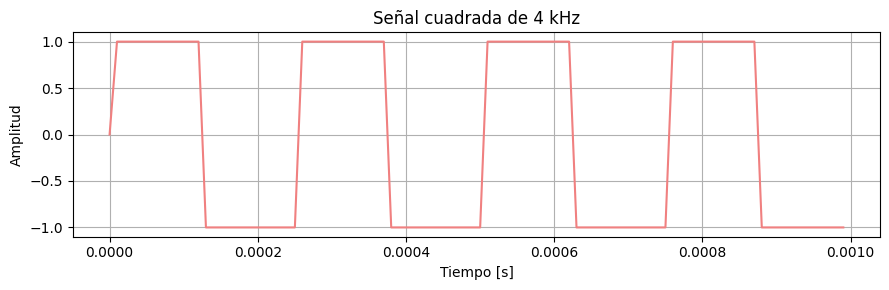

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_cuadrada(vmax, dc, ff, nn, fs):
    ts = 1/fs
    yy = np.arange(nn) * ts
    cc = dc + vmax * np.sign(np.sin(2*np.pi*ff*yy))
    return yy, cc
    
N5 = 100
fs5 = 100000
yy, cc = mi_funcion_cuadrada(vmax=1, dc=0, ff=4000, nn=N5, fs=fs5)

plt.figure(figsize=(9,3))
plt.plot(yy, cc, color='lightcoral')
plt.title("Señal cuadrada de 4 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

### Inciso 6 – Pulso rectangular de 10 ms

Se genera un único pulso rectangular de duración $\tau = 10$ ms y amplitud unitaria, muestreado a $f_s = 10\,000$ Hz con un total de $N = 1000$ muestras (lo que representa una ventana de observación de 100 ms).

**Fenómeno observable:** A diferencia de las señales periódicas anteriores, este pulso existe solo durante un intervalo finito de tiempo. Su transformada de Fourier es una función $\text{sinc}$, con lóbulo principal centrado en $f = 0$ y ancho $\propto 1/\tau$.

- **Período:** No aplica — es una señal **aperiódica**.  
- **Número de muestras activas:** $\tau \cdot f_s = 100$ muestras con valor 1; las 900 restantes valen 0.  
- **Clasificación:** Señal de **energía** ($E = \tau \cdot A^2 = 0.01$ J finita).

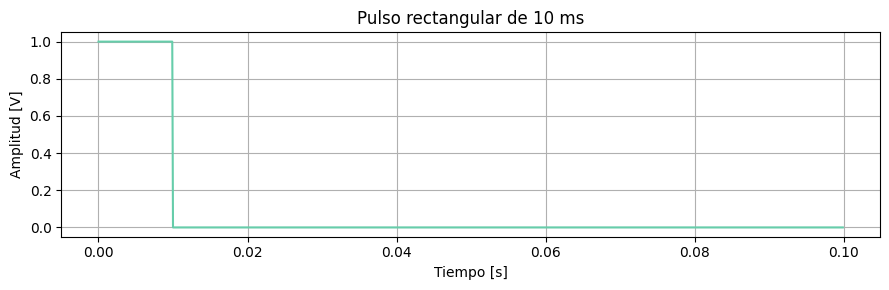

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_pulso_rect(vmax, dc, ancho, nn, fs):
    tt = np.arange(nn) / fs
    xx = np.full(nn, dc, dtype=float)
    ancho_muestras = int(ancho * fs)
    xx[:ancho_muestras] = vmax + dc
    return tt, xx

tt_rect, xx_rect = mi_funcion_pulso_rect(vmax=1, dc=0, ancho=0.010, nn=1000, fs=10000)

plt.figure(figsize=(9,3))
plt.plot(tt_rect, xx_rect, color='mediumaquamarine')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Pulso rectangular de 10 ms')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Ejercicio 2 – Sistema LTI: convolución con h[n] = δ[n] − δ[n−4]

Se analiza un sistema LTI cuya respuesta al impulso es:

$$h[n] = \delta[n] - \delta[n-4]$$

Este sistema **resta a cada muestra el valor que tenía 4 instantes antes**, funcionando como un **filtro paso-altos** o diferenciador con retardo. Señales constantes (DC) se cancelan completamente; señales que varían rápidamente producen una salida de alta amplitud.

### Respuesta al impulso h[n]

In [ ]:
N = 100
n = np.arange(0, N)
h = np.zeros(N)
h[n == 0] = 1
h[n == 4] = -1

plt.figure(figsize=(6,3))
plt.stem(n, h, linefmt='mediumaquamarine', basefmt='green')
plt.title("Respuesta al impulso: h[n] = δ[n] − δ[n−4]")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.xlim(-0.5, 6)
plt.grid()
plt.tight_layout()
plt.show()

### Inciso a – Entrada: cosinusoide discreta $x[n] = \cos(2\pi f_0 n T_s)$

Con $f_0 = 1$ Hz y $f_s = 10$ Hz, la señal de entrada es una cosinusoide de período $T = 1/f_0 = 1$ s, es decir **10 muestras por período**.

**Fenómeno observable:** El sistema aplica la diferencia $x[n] - x[n-4]$. Para una cosinusoide, esto equivale a filtrar según la respuesta en frecuencia del sistema. Como el período es de 10 muestras y el retardo es de 4 muestras ($4/10 = 144°$), la salida es otra sinusoide **de la misma frecuencia** pero con amplitud y fase modificadas:

$$y[n] = \cos(2\pi f_0 n T_s) - \cos(2\pi f_0 (n-4) T_s)$$

Se conserva la periodicidad y la forma sinusoidal — solo cambia la amplitud y la fase.

In [ ]:
fs_ej2 = 10
ts_ej2 = 1/fs_ej2
f0 = 1
x = np.cos(2*np.pi*f0*n*ts_ej2)
y_a = sig.convolve(x, h, mode='same')

fig, axes = plt.subplots(2, 1, figsize=(10,6))

axes[0].stem(n, x, linefmt='turquoise', basefmt='green')
axes[0].set_xlim(0, 20)
axes[0].set_title("x[n] = cos(2π·1·n·Ts)")
axes[0].set_ylabel("Amplitud")
axes[0].grid()

axes[1].stem(n, y_a, linefmt='teal', markerfmt='o', basefmt='green')
axes[1].set_xlim(0, 20)
axes[1].set_title("a) y[n] = x[n] * h[n]")
axes[1].set_xlabel("n [muestras]")
axes[1].set_ylabel("Amplitud")
axes[1].grid()

plt.tight_layout()
plt.show()

### Inciso b – Entrada: exponencial decreciente $x[n] = (1/2)^n \cdot u[n]$

La entrada es una **exponencial real causal** con base $0.5 < 1$, por lo que decae hacia cero a medida que $n$ aumenta. Es una señal de **energía** (la suma de sus cuadrados converge).

**Fenómeno observable:** La salida $y[n] = x[n] - x[n-4] = (1/2)^n - (1/2)^{n-4}$ también decae exponencialmente, pero con una **amplitud inicial más pronunciada** y luego se extingue más rápido que la entrada. El sistema resalta el transitorio inicial (donde la variación entre muestras es mayor) y atenúa la cola donde la señal ya casi no cambia.

In [ ]:
xb = (0.5)**n * (n >= 0)
yb = sig.convolve(xb, h, mode='same')

fig, axes = plt.subplots(2, 1, figsize=(10,6))

axes[0].stem(n, xb, linefmt='slateblue', basefmt='royalblue')
axes[0].set_title("x_b[n] = (1/2)^n · u[n]")
axes[0].set_ylabel("Amplitud")
axes[0].grid()

axes[1].stem(n, yb, linefmt='slateblue', basefmt='royalblue', label='convolución')
axes[1].set_title("b) y[n] = x_b[n] * h[n]")
axes[1].set_xlabel("n [muestras]")
axes[1].set_ylabel("Amplitud")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### Inciso c – Entrada: pulso discreto $x_c[n] = u[n+1] - u[n-2]$

La entrada es un **pulso rectangular discreto** que vale 1 en el rango $n \in \{-1, 0, 1\}$ (3 muestras activas) y cero en el resto. Es una señal de **energía** (soporte finito, energía $E = 3$).

**Fenómeno observable:** Al convolver un pulso con $h[n] = \delta[n] - \delta[n-4]$, el sistema produce **dos réplicas del pulso**: una positiva en la posición original y otra negativa desplazada 4 muestras. Donde se solapan, las contribuciones se suman algebraicamente. La salida tiene soporte finito (señal de **energía**), al igual que la entrada.

In [ ]:
xc = (n >= -1).astype(int) - (n >= 2).astype(int)  # pulso en n = -1, 0, 1 (pero n empieza en 0 → n = 0, 1)
yc = sig.convolve(xc, h, mode='same')

fig, axes = plt.subplots(2, 1, figsize=(10,6))

axes[0].stem(n, xc, linefmt='khaki', basefmt='darkkhaki')
axes[0].set_title("x_c[n] = pulso rectangular")
axes[0].set_ylabel("Amplitud")
axes[0].set_xlim(-1, 15)
axes[0].grid()

axes[1].stem(n, yc, linefmt='khaki', basefmt='darkkhaki', label='convolución')
axes[1].set_title("c) y[n] = x_c[n] * h[n]")
axes[1].set_xlabel("n [muestras]")
axes[1].set_ylabel("Amplitud")
axes[1].set_xlim(-1, 15)
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

---
## Conclusiones

- Las señales sinusoidales y cuadradas periódicas son **señales de potencia**: poseen energía infinita pero potencia media finita y no nula.
- El pulso rectangular de duración finita es una **señal de energía**: su energía total es finita y su potencia media es cero.
- La **modulación AM** traslada el espectro de la señal mensaje a la frecuencia portadora, generando bandas laterales simétricas visibles en la FFT.
- La **saturación** introduce armónicos que no estaban en la señal original, siendo una fuente de distorsión no lineal.
- El sistema LTI $h[n] = \delta[n] - \delta[n-4]$ actúa como **filtro diferenciador**: atenúa componentes constantes y realza cambios rápidos, con efectos distintos según el tipo de señal de entrada (sinusoide, exponencial o pulso).